# The curse of dimensionality

Many machine learning problems involve thousands or even millions of features per training instance. This can significantly reduce the training speed and also make it harder to find a good solution to the problem. 

Fortunately, in real-world problems, we can often reduce the number of features in a problem since not all of the features are necessary to get a good solution. For example, we can remove the border pixels in the mnist database since they don't contain any useful information that the model can use. 

In addition to speeding up the training, dimensionality reduction also helps us visualize the data by projecting it into a lower dimension that we can plot. 

__Note:__ By reducing the number of features, we are also reducing the information contained in the input, which might reduce the accuracy of the model, but increases the training speed. 


The problem with high dimensions is that the more dimensions you have, the more distance there is between training instances, which makes it hard for the model to reliably group instances in a specific category.

A solution to this problem would be to increase the number of training instances, which increases the density of the training set. However, this solution isn't alway possible because collecting more training samples might be expensive.

## Main Approaches for Dimensionality Reduction

In most real-world problems, training instances are not uniformly spread out across all dimensions. Many features are constant, while others are highly correlated. As a result, all training instances lie within a much lower-dimensional _subspace_ of the high dimensional space. 

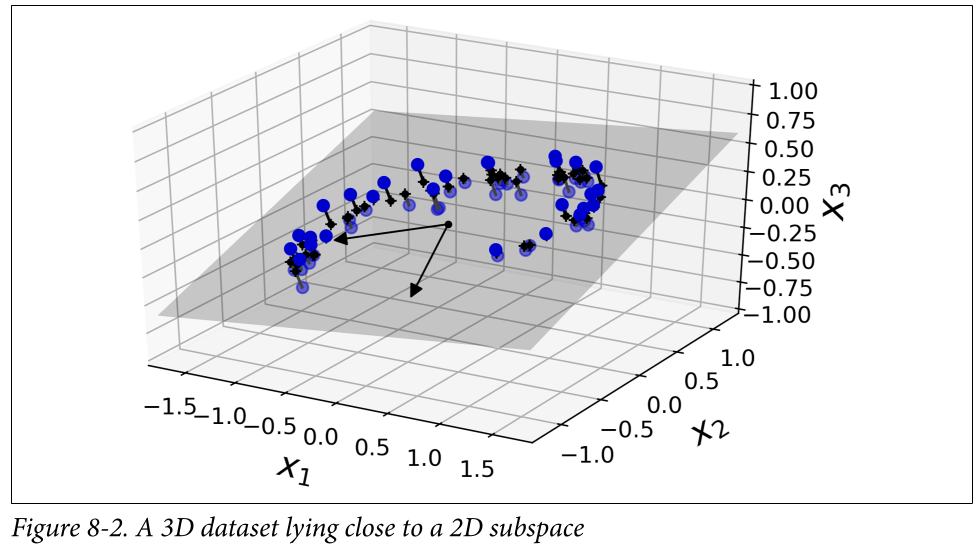

In the example dataset above, we can see that the training instances are close to a 2D plane in this 3D space. We can simply project all the points perpendicularly onto this subspace, which reduces the dimensions of each point and makes them 2D!

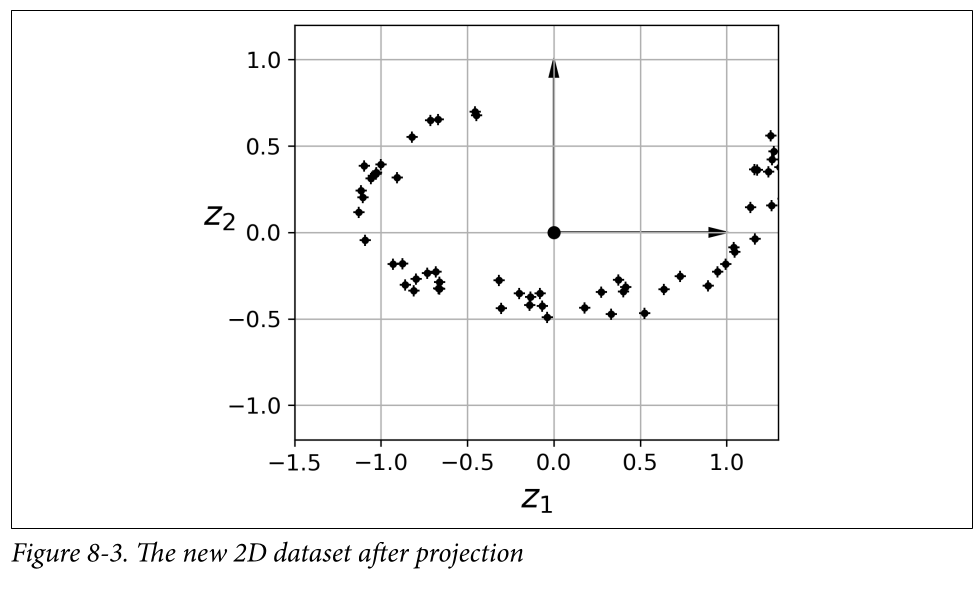

Projection doesn't always work because some datasets may twist and turn on themselves, which makes it impossible to simply drop one axis to reduce the number of dimensions.

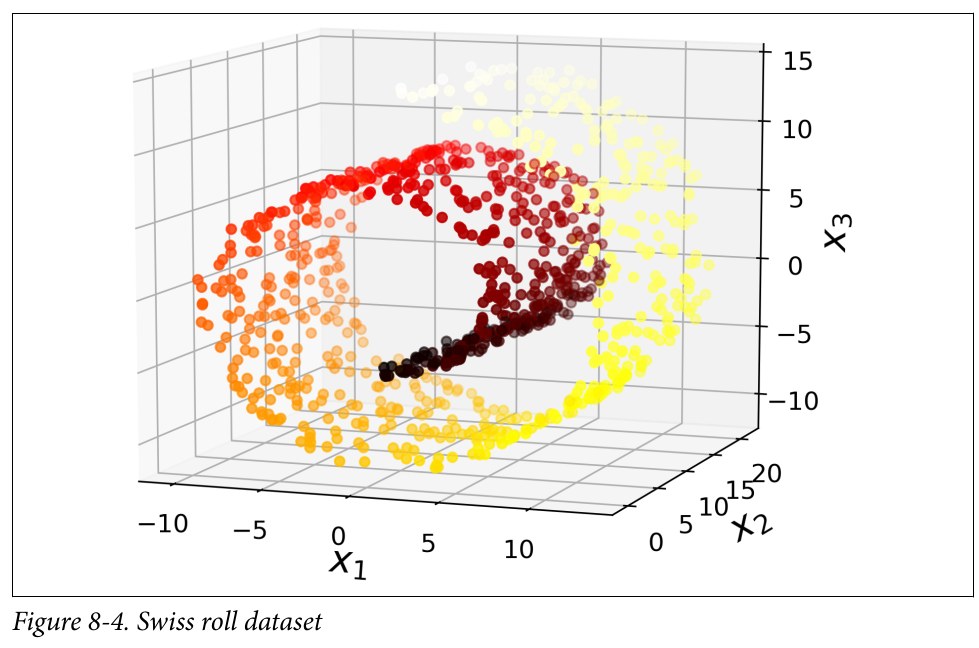

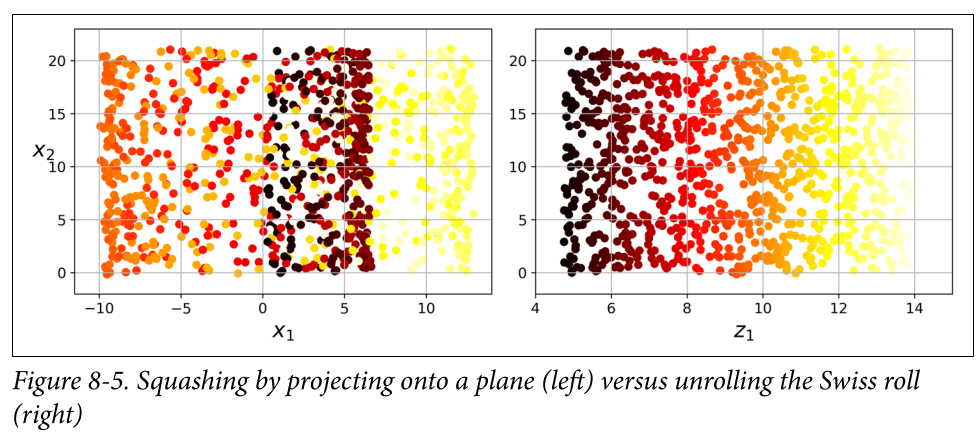

What we want, is to unfold the training set to obtain the 2D dataset!

## Manifold Learning


The Swiss roll dataset shown above is an example of a 2D _manifold_, which simply means a 2D shape that can be bent and twisted in a higher dimensional space. 

Generally, a d-dimensional manifold is a part of an n-dimensional space (where d < n) that locally resembles a d-dimensional hyperplane. In the case of the swiss roll dataset, d = 2, n = 3, and the dataset is locally 2D, but it is folded on itself in the third dimension!

Many dimensionality reduction algorithms work by modelling the manifold on which the training instances lie; this is called _Manifold Learning_. It relies on the assumption that the dataset lies close to a lower dimension within the high dimensional space.

Manifold learning also relies on another assumption that the problem at hand would be much simpler in the lower dimension. However, this is not always the case. Take a look at the following figure:

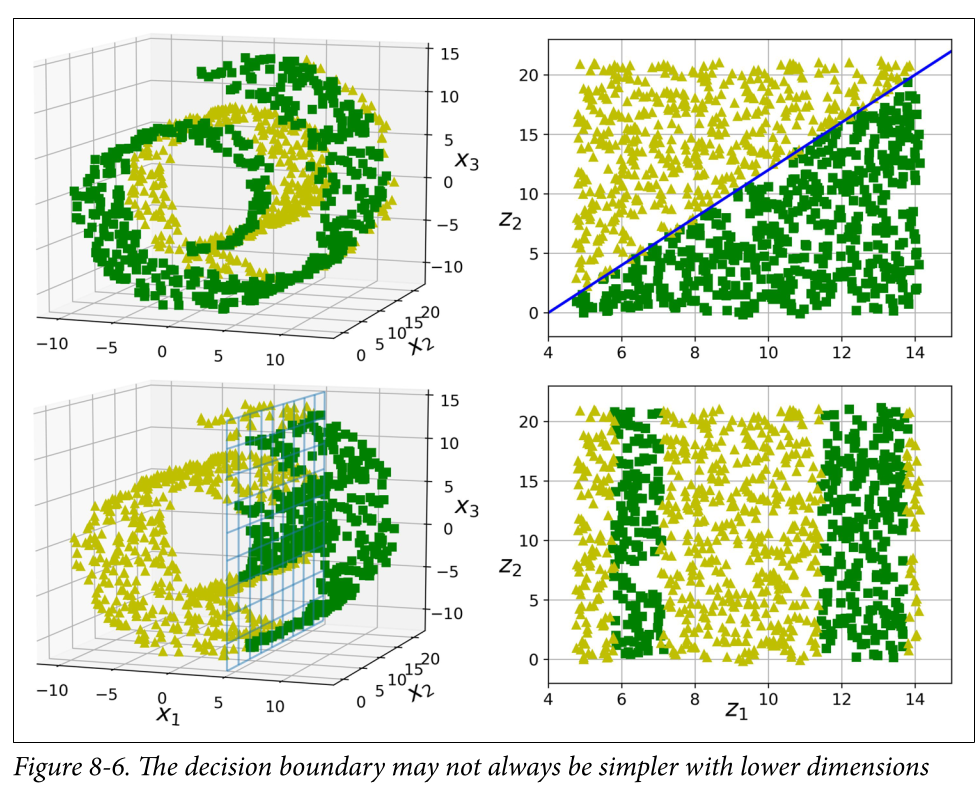

## PCA
PCA (Principal Component Analysis) is by far the most popular dimensionality reduction algorithm, and it works by first finding the hyperplane that is closest to the dataset, and then projecting the dataset on that hyperplane.

### Preserving the Variance
Before projecting your data onto a hyperplane, you need to find the right one to project onto it. This can be done by choosing the hyperplane that preserves the most amount of variance since this means that the projection will not cause that much information loss if done onto a hyperplane that preserves the original variance of the data.

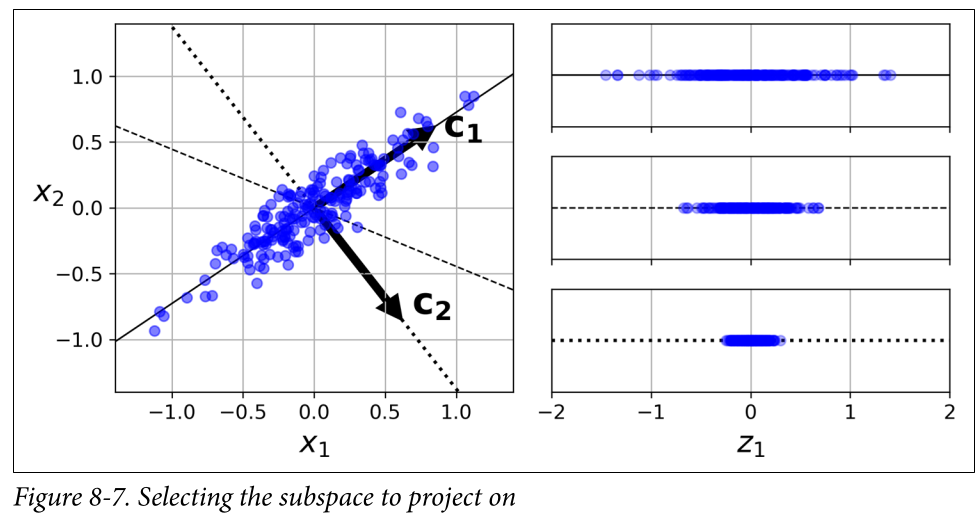


### Principal Components
PCA identifies the axis that accounts for the largest amount of variance in the training set. After that, it finds a second axis orthogonal to the first one, which accounts for the remaining variance. PCA finds as many axes as the number of dimensions in the training set. The $j^{th}$ axis PCA finds is called the $j^{th}$ PC (principal component) of the data.

Finding the PCs of a training set is done using SVD (Singular Value Decomposition), which decomposes the training set matrix X into a matrix multiplication of the matrices $U\ \sum\ V^T$, where $V$ contains the unit vectors that define all the principal components that we are looking for.

The following code shows this in python:

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
import numpy as np
mnist = fetch_openml('mnist_784', version = 1)
X, y = mnist['data'].to_numpy(), mnist['target'].to_numpy()


In [3]:
X_centered = X - X.mean(axis = 0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

In [ ]:
c1, c2

(array([-1.09520765e-19, -1.11022302e-16,  2.22044605e-16,  0.00000000e+00,
         0.00000000e+00,  5.55111512e-17,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.35525272e-20,  0.00000000e+00,
         0.00000000e+00, -2.11758237e-22,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -3.76158192e-37,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  7.17464814e-43,  0.00000000e+00,
         0.00000000e+00,  8.75811540e-47,  3.90009826e-47, -1.33715688e-05,
        -4.80634881e-05, -5.83768802e-05, -5.39099512e-05, -8.19409274e-05,
        -5.07857216e-05, -1.27893711e-04, -1.68312326e-04, -7.19793677e-05,
        -1.00012738e-05, -1.04240210e-04, -1.06563884e-04,  1.75714903e-06,
        -7.49274614e-07,  4.55569088e-06,  3.60354273e-06, -3.87027799e-06,
         0.0

Reducing the dimensions of the dataset is done by projecting the dataset onto a the hyperplane that made of the first $d$ PCs, which ensures that the projection preserves as much variance as possible. 

This can be done using the following equation:

$X_{d-proj} = XW_{d}$

where $W_{d}$ is a matrix containing the first d columns of V.

In [ ]:
W2 = Vt.T[:, :2]
X2D = X_centered.dot(W2) #Get the new reduced dataset!

In [ ]:
X2D.shape, X.shape

Now using scikit-learn for PCA!

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X2D = pca.fit_transform(X)

In [5]:
X2D.shape, X.shape

((70000, 2), (70000, 784))

In [6]:
pca.components_.T[:, 0] #get the first PC

array([-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -9.45584907e-07, -3.72373918e-06, -1.83973346e-06, -7.66555610e-08,
       -1.11022302e-16, -2.77555756e-17, -0.00000000e+00, -0.00000000e+00,
        4.33680869e-19, -1.08420217e-19, -2.71050543e-20, -1.35525272e-20,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  6.61744490e-24,
       -0.00000000e+00,  5.16987883e-26, -3.23117427e-27,  4.03896783e-28,
        2.16824828e-07,  4.29492620e-07,  4.87706215e-06,  1.65229866e-05,
        2.20363253e-05,  3.88808469e-05,  7.40607809e-05,  8.83248604e-05,
        8.08496291e-05,  8.95693486e-05,  1.06176520e-04,  7.93597126e-05,
        3.60812098e-05,  3.08090474e-05,  2.39076582e-05,  3.64534622e-06,
       -2.94191043e-06,  1.88455271e-06,  1.14903055e-06,  4.83408762e-07,
       -0.00000000e+00, -

A useful attribute of the PCA class in scikit-learn is the _explained variance ratio_, which tells you the percentage of the original variance each PC explains.

In [7]:
pca.explained_variance_ratio_

array([0.09746116, 0.07155445])

The output says that we can get 10.2% of the original variance by using the first PC.

You can use this attribute to decide how many PCs you want to use instead of choosing arbitrarily.

In [8]:
pca = PCA() #train as many components as there are dimensions in the dataset
pca.fit(X)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1


In [9]:
d # the number of components you need to get 95% of the original variance!

154

In [10]:
pca.explained_variance_ratio_

array([9.74611592e-02, 7.15544459e-02, 6.14953098e-02, 5.40338453e-02,
       4.88893370e-02, 4.30522703e-02, 3.27826152e-02, 2.88964157e-02,
       2.75836420e-02, 2.34214017e-02, 2.10668855e-02, 2.03755324e-02,
       1.70706430e-02, 1.69401978e-02, 1.58338224e-02, 1.48634490e-02,
       1.31935849e-02, 1.27901425e-02, 1.18727249e-02, 1.15293670e-02,
       1.06603978e-02, 1.00979434e-02, 9.59151230e-03, 9.09635078e-03,
       8.83286819e-03, 8.38818208e-03, 8.09831794e-03, 7.85717898e-03,
       7.40262230e-03, 6.90014160e-03, 6.56143991e-03, 6.45470291e-03,
       6.00819302e-03, 5.85611746e-03, 5.66753559e-03, 5.43470659e-03,
       5.04717070e-03, 4.87079420e-03, 4.78955138e-03, 4.67593650e-03,
       4.54368629e-03, 4.44918011e-03, 4.18216598e-03, 3.96163907e-03,
       3.83707746e-03, 3.75784804e-03, 3.61426284e-03, 3.49024600e-03,
       3.38731603e-03, 3.19696169e-03, 3.16854028e-03, 3.10144912e-03,
       2.96480352e-03, 2.87101448e-03, 2.82513796e-03, 2.69422713e-03,
      

There is a much better option than running the previous code. You can simply just invoke the PCA class with the fraction of variance that you want to preserve as follows:

In [11]:
pca = PCA(n_components = 0.95)
X_reduced = pca.fit_transform(X)

Another option is to plot the explained variance as a function of dimensions added as follows:


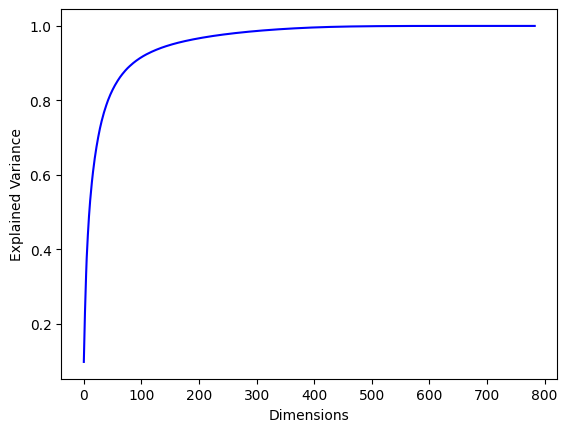

In [12]:
from matplotlib import pyplot as plt
plt.plot(cumsum, 'b-')
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance')
plt.show()

The Elbow of the curve above is a good choice for the number of dimensions to keep in the PCA transformation.

## PCA for Compression


In the previous example, we used PCA to preserve 95% of the original variance while reducing the number of features from 784 to 150! This is a reasonable compression ratio that can significantly speed up the training process of an algorithm such as SVM classifier.

It is also possible to recover the original data by applying the inverse transformation as follows:

In [13]:
pca = PCA(n_components=150)
X_reduced = pca.fit_transform(X)
X_recovered = pca.inverse_transform(X_reduced)

In [14]:
X_reduced.shape, X_recovered.shape, X.shape

((70000, 150), (70000, 784), (70000, 784))

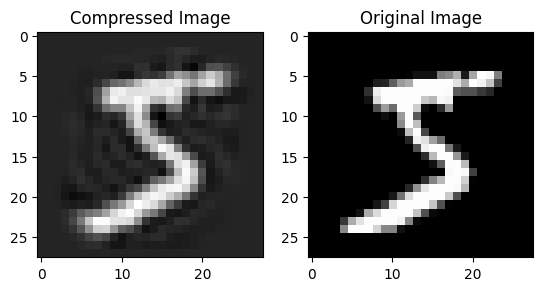

In [15]:
plt.subplot(1,2,1)
plt.title('Compressed Image')
plt.imshow(X_recovered[0].reshape(28,28), cmap = plt.cm.gray)
plt.subplot(1,2,2)
plt.title('Original Image')
plt.imshow(X[0].reshape(28,28), cmap = plt.cm.gray)
plt.show()

## Randomized PCA
If you set the svd_solver hyperparameter to "Randomized", scikit-learn uses a stochastic algorithm called Randomized PCA that quickly finds an approximation of the first d principal components.

Computational complexity of randomized pca:

$O(m*d^2) + O(d^3)$

Computational complexity of regular pca:

$O(m*n^2) + O(n^3)$

In [16]:
rnd_pca = PCA(n_components=150, svd_solver = 'randomized')
X_reduced = rnd_pca.fit_transform(X)

The default in scikit-learn is that it figures out whether to use random pca or full pca based on the values of m, n, and d. (m = training instances, n = number of features, d = desired number of features).

You can force scikit-learn to use the full pca by setting svd_solver = 'full'.

## Incremental PCA

Incremental pca allows you to perform pca on a large set by training it on mini-batches of the training set instead of the whole dataset.  

In [ ]:
from sklearn.decomposition import IncrementalPCA
n_batches = 100
X = mnist['data'].to_numpy() #load the whole mnist database

inc_pca = IncrementalPCA(n_components=150)

for i, X_batch in enumerate(np.array_split(X, n_batches)):
    print(f'Batch {i + 1} out of {n_batches}.')
    inc_pca.partial_fit(X)

X_reduced = inc_pca.transform(X)    

In [ ]:
# you can also use incremental pca as follows:
inc_pca = IncrementalPCA(n_components=150, batch_size = X.shape[0]//n_batches)
inc_pca.fit(X)

IncrementalPCA(batch_size=700, n_components=150)

## Kernel PCA

Kernel PCA utilizes the kernel trick discussed for SVMs to perform nonlinear projections for dimensionality reduction.

In [3]:
from sklearn.decomposition import KernelPCA
rbf_pca = KernelPCA(n_components=150, kernel = 'rbf', gamma = 0.4)
rbf_pca.fit(X)

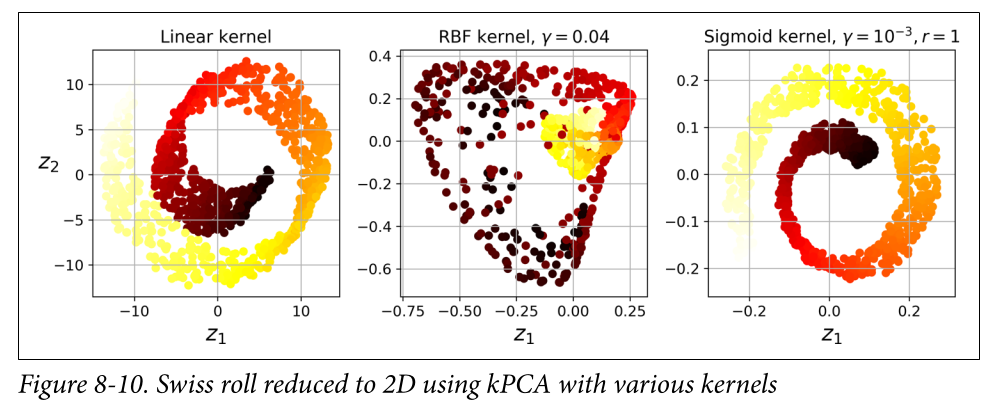

Now lets create a program that puts PCA to use in a scikit-learn pipeline: 

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = X[:50000], X[50000:], y[:50000], y[50000:]

clf = Pipeline([
    ('inc_pca', IncrementalPCA(n_components=150, batch_size = 150)),
    ('log_reg', LogisticRegression(max_iter = 10000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9236

You can also determine the best kernel to use by determining the kernel that yields the best reconstruction error. However, reconstruction is not as easy as with learn PCA. 

The trick to performing the reconstruction is by training a supervised regression model that takes the projected instances as the training set and outputs the original instances as the target. 

The following code shows this:

In [ ]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel = 'rbf', gamma = 0.0433,
                    fit_inverse_transform=True)

X_reduced = rbf_pca.fit_transform(X)
X_preimage = rbf_pca.inverse_transform(X_reduced)


## LLE

Locally Linear Embedding (LLE) is a nonlinear dimensionality reduction technique that doesn't rely on projections like PCA. Instead, it measures how each training instance linearly relates to its closest neighbors, and then looks for a low-dimensional representation that best preserves these relationships.  


In [2]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components = 2, n_neighbors = 10)
X_reduced = lle.fit_transform(X)

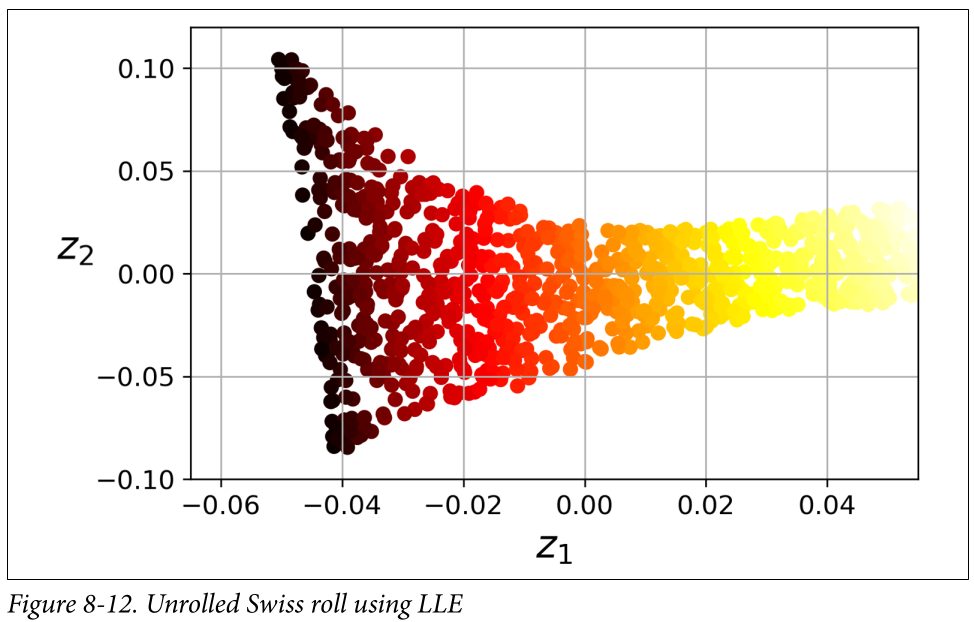

LLE works by identifying the k closest neighbors to the training instance $x^{(i)}$, and tries to reconstruct the instance using a linear function of the neighbors around it. The linear function used is:

$\sum_{j = 1}^{m} w_{i, j}x^{(j)}$

Assuming $w_{i, j} = 0$ if $x^{(j)}$ is not one of the k closest neighbors of $x^{(i)}$.

Also, the sum of the weights $\sum_{j = 1}^{m} w_{i, j} = 1$ for i = 1,2,3,...m

LLE can be described using the following constrained optimization problem:

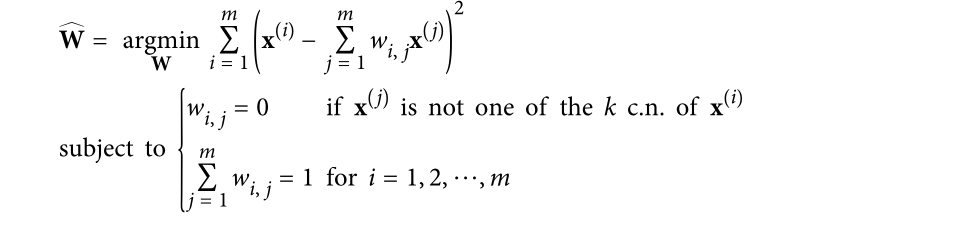

After we find $\hat{W}$, which basically encodes the linear relationships between the instances, we now try to find a lower dimensional representation of the training instances such that these relationships are preserved as much as possible.

Basically, we want the squared distance between $z^{(i)}$ and $\sum_{j = 1}^{m}\hat{W}_{i, j}z^{(j)}$ to be as small as possible.

__Note:__ z is the lower dimensional image of x.

Reducing the training set is described by the following unconstrained optimization problem:

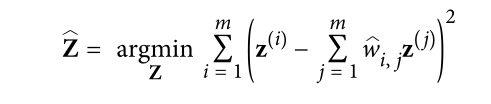